In [1]:
# pip install tenseal numpy scikit-learn pandas

## Klasyfikator binarny

In [2]:
import tenseal as ts
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [3]:
iris = load_iris()
MOD_DEG = 8192

X = iris.data[:100, :]
y = iris.target[:100]
print("Number of features: ", X.shape[1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Number of features:  4


In [4]:
model = LogisticRegression()

model.fit(X_train, y_train)

weights = model.coef_[0]
bias = model.intercept_[0]

print("Wytrenowane wagi:", weights)
print("Bias:", bias)

Wytrenowane wagi: [ 0.46248518 -0.84445753  2.21233212  0.92744332]
Bias: -6.524475408258978


In [5]:
context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=MOD_DEG,
    coeff_mod_bit_sizes=[60, 40, 40, 60]
)

context.global_scale = 2**40

context.generate_galois_keys()

In [6]:
sample = X_test[0]

print("Próbka testowa:")
print(sample)

encrypted_sample = ts.ckks_vector(context, sample)

Próbka testowa:
[6.  2.7 5.1 1.6]


In [7]:
encrypted_result = encrypted_sample.dot(weights) + bias

print("Zaszyfrowany wynik:")
print(encrypted_result)

Zaszyfrowany wynik:


In [8]:
decrypted_result = encrypted_result.decrypt()[0]

print("Odszyfrowany wynik:", decrypted_result)

predicted_class = int(decrypted_result > 0)

print("Przewidziana klasa:", predicted_class)
print("Prawdziwa klasa:", y_test[0])

Odszyfrowany wynik: 6.73720582253691
Przewidziana klasa: 1
Prawdziwa klasa: 1


## Klasyfikacja wieloklasowa

In [4]:
import tenseal as ts
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, f1_score

In [5]:
iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
print(LogisticRegression)

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [6]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [7]:
context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=MOD_DEG,
    coeff_mod_bit_sizes=[60, 40, 40, 60]
)

context.global_scale = 2**40

context.generate_galois_keys()

In [8]:
sample = X_test[0]
true_class = y_test[0]

print("Próbka testowa:")
print(sample)

encrypted_sample = ts.ckks_vector(context, sample)

Próbka testowa:
[6.1 2.8 4.7 1.2]


In [9]:
# Dla każdej klasy:
# score = w*x + b

encrypted_scores = []

for i in range(len(model.classes_)):

    weights = model.coef_[i]
    bias = model.intercept_[i]

    # obliczenia homomorficzne
    encrypted_score = encrypted_sample.dot(weights) + bias

    encrypted_scores.append(encrypted_score)

In [10]:
scores = []

for i, enc_score in enumerate(encrypted_scores):

    decrypted_score = enc_score.decrypt()[0]

    scores.append(decrypted_score)

    print(f"Wynik dla klasy {i}: {decrypted_score}")

Wynik dla klasy 0: -3.0585089478357452
Wynik dla klasy 1: 2.325145861265235
Wynik dla klasy 2: 0.7333608308275545


In [11]:
predicted_class = np.argmax(scores)

print("Przewidziana klasa:", predicted_class)
print("Prawdziwa klasa:", true_class)

Przewidziana klasa: 1
Prawdziwa klasa: 1


In [12]:
predictions = []

for idx, sample in enumerate(X_test):

    true_class = y_test[idx]

    # Szyfrowanie próbki
    encrypted_sample = ts.ckks_vector(context, sample)

    # Klasyfikacja homomorficzna
    encrypted_scores = []

    for i in range(len(model.classes_)):
        weights = model.coef_[i]
        bias = model.intercept_[i]

        encrypted_score = encrypted_sample.dot(weights) + bias
        encrypted_scores.append(encrypted_score)

    # Odszyfrowanie wyników
    scores = []
    for enc_score in encrypted_scores:
        decrypted_score = enc_score.decrypt()[0]
        scores.append(decrypted_score)

    # Predykcja klasy
    predicted_class = np.argmax(scores)
    predictions.append(predicted_class)

#Metryki jakości klasyfikacji
predictions = np.array(predictions)
accuracy = accuracy_score(y_test, predictions)

precision = precision_score(
    y_test,
    predictions,
    average="weighted"
)

f1 = f1_score(
    y_test,
    predictions,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 1.0000
Precision: 1.0000
F1-Score : 1.0000


## Klasyfikator homomorficzny dla zbioru Breast Cancer Wisconsin

Poniżej znajduje się analogiczny klasyfikator dla innego zbioru danych. Model jest trenowany na danych jawnych, a podczas klasyfikacji próbka wejściowa jest szyfrowana. Serwer wykonuje tylko operacje homomorficzne na zaszyfrowanym wektorze cech, więc wynik liniowy klasyfikatora pozostaje zaszyfrowany do momentu odszyfrowania przez właściciela danych.

In [13]:
import tenseal as ts
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [14]:
breast_cancer = load_breast_cancer()

X_bc = breast_cancer.data
y_bc = breast_cancer.target

X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc,
    y_bc,
    test_size=0.2,
    random_state=42,
    stratify=y_bc
)

scaler = StandardScaler()
X_bc_train_scaled = scaler.fit_transform(X_bc_train)
X_bc_test_scaled = scaler.transform(X_bc_test)

print("Zbior danych:", breast_cancer.DESCR.splitlines()[0])
print("Liczba probek:", X_bc.shape[0])
print("Liczba cech:", X_bc.shape[1])
print("Klasy:", dict(enumerate(breast_cancer.target_names)))

Zbior danych: .. _breast_cancer_dataset:
Liczba probek: 569
Liczba cech: 30
Klasy: {0: np.str_('malignant'), 1: np.str_('benign')}


In [15]:
bc_model = LogisticRegression(max_iter=2000, random_state=42)
bc_model.fit(X_bc_train_scaled, y_bc_train)

bc_weights = bc_model.coef_[0]
bc_bias = bc_model.intercept_[0]

plain_predictions = bc_model.predict(X_bc_test_scaled)

print("Liczba wag modelu:", len(bc_weights))
print("Bias:", bc_bias)
print(f"Accuracy modelu jawnego: {accuracy_score(y_bc_test, plain_predictions):.4f}")

Liczba wag modelu: 30
Bias: 0.30220757353702754
Accuracy modelu jawnego: 0.9825


In [16]:
BC_MOD_DEG = 8192

bc_context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=BC_MOD_DEG,
    coeff_mod_bit_sizes=[60, 40, 40, 60]
)

bc_context.global_scale = 2**40
bc_context.generate_galois_keys()

In [17]:
def encrypted_breast_cancer_score(sample_scaled):
    encrypted_sample = ts.ckks_vector(bc_context, sample_scaled)
    return encrypted_sample.dot(bc_weights) + bc_bias


def decrypt_score_and_predict(encrypted_score):
    score = encrypted_score.decrypt()[0]
    predicted_class = int(score > 0)
    return score, predicted_class

In [18]:
sample_idx = 0
sample_scaled = X_bc_test_scaled[sample_idx]
true_class = y_bc_test[sample_idx]

encrypted_score = encrypted_breast_cancer_score(sample_scaled)
decrypted_score, predicted_class = decrypt_score_and_predict(encrypted_score)

print("Zaszyfrowany wynik:")
print(encrypted_score)
print("Odszyfrowany score:", decrypted_score)
print("Przewidziana klasa:", predicted_class, breast_cancer.target_names[predicted_class])
print("Prawdziwa klasa:", true_class, breast_cancer.target_names[true_class])

Zaszyfrowany wynik:
Odszyfrowany score: -16.64772318095237
Przewidziana klasa: 0 malignant
Prawdziwa klasa: 0 malignant


In [19]:
encrypted_predictions = []
decrypted_scores = []

for sample_scaled in X_bc_test_scaled:
    encrypted_score = encrypted_breast_cancer_score(sample_scaled)
    decrypted_score, predicted_class = decrypt_score_and_predict(encrypted_score)

    decrypted_scores.append(decrypted_score)
    encrypted_predictions.append(predicted_class)

encrypted_predictions = np.array(encrypted_predictions)

accuracy = accuracy_score(y_bc_test, encrypted_predictions)
precision = precision_score(y_bc_test, encrypted_predictions)
recall = recall_score(y_bc_test, encrypted_predictions)
f1 = f1_score(y_bc_test, encrypted_predictions)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print("Macierz pomylek:")
print(confusion_matrix(y_bc_test, encrypted_predictions))

Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-Score : 0.9861
Macierz pomylek:
[[41  1]
 [ 1 71]]


## Wieloklasowy klasyfikator homomorficzny dla zbioru Letter Recognition

Ta sekcja wykorzystuje realny zbiór `letter` z OpenML: 20000 próbek opisujących wielkie litery alfabetu za pomocą 16 cech numerycznych. Tym razem klasyfikator rozpoznaje każdą literę osobno, czyli działa na 26 klasach `A-Z`. Dla każdej klasy model ma osobny wektor wag, a serwer homomorficznie liczy 26 zaszyfrowanych score'ów `w_i*x + b_i`. Właściciel danych odszyfrowuje score'y i lokalnie wybiera klasę z największą wartością (`argmax`).

In [21]:
# Jesli matplotlib nie jest zainstalowany w srodowisku, odkomentuj:
# !pip install matplotlib

import os
import time
import tenseal as ts
import numpy as np

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [22]:
letter_data = fetch_openml(
    name="letter",
    version=1,
    as_frame=False,
    parser="liac-arff",
    data_home="./sklearn_data"
)

X_letter = letter_data.data.astype(np.float64)
letter_labels = letter_data.target.astype(str)

target_names = np.array(sorted(np.unique(letter_labels)))
letter_to_id = {letter: idx for idx, letter in enumerate(target_names)}
y_letter = np.array([letter_to_id[label] for label in letter_labels])

X_letter_train, X_letter_test, y_letter_train, y_letter_test = train_test_split(
    X_letter,
    y_letter,
    test_size=0.2,
    random_state=42,
    stratify=y_letter
)

letter_scaler = StandardScaler()
X_letter_train_scaled = letter_scaler.fit_transform(X_letter_train)
X_letter_test_scaled = letter_scaler.transform(X_letter_test)

print("Zbior danych: OpenML letter")
print("Liczba probek:", X_letter.shape[0])
print("Liczba cech:", X_letter.shape[1])
print("Rozmiar train/test:", X_letter_train_scaled.shape, X_letter_test_scaled.shape)
print("Liczba klas:", len(target_names))
print("Klasy:", target_names)
print("Rozklad klas:", dict(zip(target_names, np.bincount(y_letter))))


Zbior danych: OpenML letter
Liczba probek: 20000
Liczba cech: 16
Rozmiar train/test: (16000, 16) (4000, 16)
Liczba klas: 26
Klasy: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
Rozklad klas: {np.str_('A'): np.int64(789), np.str_('B'): np.int64(766), np.str_('C'): np.int64(736), np.str_('D'): np.int64(805), np.str_('E'): np.int64(768), np.str_('F'): np.int64(775), np.str_('G'): np.int64(773), np.str_('H'): np.int64(734), np.str_('I'): np.int64(755), np.str_('J'): np.int64(747), np.str_('K'): np.int64(739), np.str_('L'): np.int64(761), np.str_('M'): np.int64(792), np.str_('N'): np.int64(783), np.str_('O'): np.int64(753), np.str_('P'): np.int64(803), np.str_('Q'): np.int64(783), np.str_('R'): np.int64(758), np.str_('S'): np.int64(748), np.str_('T'): np.int64(796), np.str_('U'): np.int64(813), np.str_('V'): np.int64(764), np.str_('W'): np.int64(752), np.str_('X'): np.int64(787), np.str_('Y'): np.int64(786), np.str_('Z'): np.int64

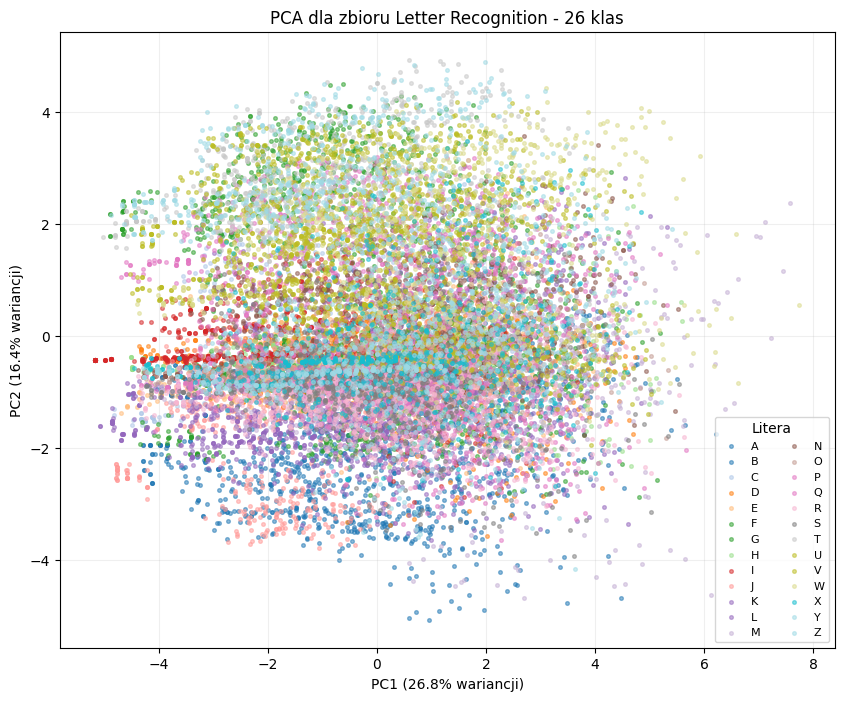

Suma wariancji wyjasnionej przez 2 skladowe PCA: 0.4320570447437518


In [23]:
pca = PCA(n_components=2, random_state=42)
X_letter_pca = pca.fit_transform(letter_scaler.transform(X_letter))

plt.figure(figsize=(10, 8))
cmap = plt.get_cmap("tab20", len(target_names))

for class_id, class_name in enumerate(target_names):
    mask = y_letter == class_id
    plt.scatter(
        X_letter_pca[mask, 0],
        X_letter_pca[mask, 1],
        s=7,
        alpha=0.5,
        color=cmap(class_id),
        label=class_name
    )

plt.title("PCA dla zbioru Letter Recognition - 26 klas")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% wariancji)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% wariancji)")
plt.legend(title="Litera", ncol=2, fontsize=8)
plt.grid(alpha=0.2)
plt.show()

print("Suma wariancji wyjasnionej przez 2 skladowe PCA:", pca.explained_variance_ratio_.sum())


In [24]:
letter_model = LogisticRegression(max_iter=3000, random_state=42)
letter_model.fit(X_letter_train_scaled, y_letter_train)

letter_weights = letter_model.coef_
letter_biases = letter_model.intercept_

letter_plain_scores = letter_model.decision_function(X_letter_test_scaled)
letter_plain_predictions = letter_model.predict(X_letter_test_scaled)

print("Ksztalt macierzy wag:", letter_weights.shape)
print("Liczba biasow:", letter_biases.shape[0])
print(f"Accuracy modelu jawnego: {accuracy_score(y_letter_test, letter_plain_predictions):.4f}")
print(f"Precision weighted modelu jawnego: {precision_score(y_letter_test, letter_plain_predictions, average="weighted"):.4f}")
print(f"Recall weighted modelu jawnego: {recall_score(y_letter_test, letter_plain_predictions, average="weighted"):.4f}")
print(f"F1 weighted modelu jawnego: {f1_score(y_letter_test, letter_plain_predictions, average="weighted"):.4f}")


Ksztalt macierzy wag: (26, 16)
Liczba biasow: 26
Accuracy modelu jawnego: 0.7695
Precision weighted modelu jawnego: 0.7699
Recall weighted modelu jawnego: 0.7695
F1 weighted modelu jawnego: 0.7687


In [25]:
LETTER_MOD_DEG = 8192

letter_context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=LETTER_MOD_DEG,
    coeff_mod_bit_sizes=[60, 40, 40, 60]
)

letter_context.global_scale = 2**40
letter_context.generate_galois_keys()


In [26]:
def encrypted_letter_scores(sample_scaled):
    encrypted_sample = ts.ckks_vector(letter_context, sample_scaled)
    encrypted_scores = []

    for class_id in range(len(target_names)):
        encrypted_score = encrypted_sample.dot(letter_weights[class_id]) + letter_biases[class_id]
        encrypted_scores.append(encrypted_score)

    return encrypted_scores


def decrypt_letter_scores_and_predict(encrypted_scores):
    scores = np.array([encrypted_score.decrypt()[0] for encrypted_score in encrypted_scores])
    predicted_class = int(np.argmax(scores))
    return scores, predicted_class


In [27]:
letter_sample_idx = 0
letter_sample_scaled = X_letter_test_scaled[letter_sample_idx]
letter_true_class = y_letter_test[letter_sample_idx]

letter_encrypted_scores = encrypted_letter_scores(letter_sample_scaled)
letter_decrypted_scores, letter_predicted_class = decrypt_letter_scores_and_predict(letter_encrypted_scores)

top_scores = np.argsort(letter_decrypted_scores)[-5:][::-1]

print("Liczba zaszyfrowanych scoreow:", len(letter_encrypted_scores))
print("Przewidziana litera:", target_names[letter_predicted_class])
print("Prawdziwa litera:", target_names[letter_true_class])
print("Top 5 scoreow po odszyfrowaniu:")

for class_id in top_scores:
    print(f"{target_names[class_id]}: {letter_decrypted_scores[class_id]:.6f}")


Liczba zaszyfrowanych scoreow: 26
Przewidziana litera: R
Prawdziwa litera: R
Top 5 scoreow po odszyfrowaniu:
R: 14.433086
K: 6.998258
O: 6.925550
H: 6.558178
G: 5.944154


In [28]:
# Pelny test ma 4000 probek, a kazda probka wymaga 26 scoreow homomorficznych.
# Zeby notebook wykonywal sie rozsadnie szybko, domyslnie bierzemy po kilka probek z kazdej litery.
HOMOMORPHIC_SAMPLES_PER_CLASS = 5
rng = np.random.default_rng(42)
homomorphic_indices = []

for class_id in range(len(target_names)):
    class_indices = np.flatnonzero(y_letter_test == class_id)
    selected_indices = rng.choice(
        class_indices,
        size=min(HOMOMORPHIC_SAMPLES_PER_CLASS, len(class_indices)),
        replace=False
    )
    homomorphic_indices.extend(selected_indices)

homomorphic_indices = np.array(sorted(homomorphic_indices))

X_letter_he_test = X_letter_test_scaled[homomorphic_indices]
y_letter_he_test = y_letter_test[homomorphic_indices]
letter_plain_scores_he = letter_plain_scores[homomorphic_indices]
letter_plain_predictions_he = letter_plain_predictions[homomorphic_indices]

print("Liczba probek do testu homomorficznego:", len(X_letter_he_test))
print("Liczba probek na klase:", HOMOMORPHIC_SAMPLES_PER_CLASS)


Liczba probek do testu homomorficznego: 130
Liczba probek na klase: 5


In [29]:
letter_encrypted_predictions = []
letter_decrypted_scores = []

start_time = time.perf_counter()

for sample_scaled in X_letter_he_test:
    encrypted_scores = encrypted_letter_scores(sample_scaled)
    decrypted_scores, predicted_class = decrypt_letter_scores_and_predict(encrypted_scores)

    letter_decrypted_scores.append(decrypted_scores)
    letter_encrypted_predictions.append(predicted_class)

elapsed_time = time.perf_counter() - start_time

letter_encrypted_predictions = np.array(letter_encrypted_predictions)
letter_decrypted_scores = np.array(letter_decrypted_scores)
score_errors = np.abs(letter_decrypted_scores - letter_plain_scores_he)

accuracy = accuracy_score(y_letter_he_test, letter_encrypted_predictions)
precision = precision_score(y_letter_he_test, letter_encrypted_predictions, average="weighted", zero_division=0)
recall = recall_score(y_letter_he_test, letter_encrypted_predictions, average="weighted", zero_division=0)
f1 = f1_score(y_letter_he_test, letter_encrypted_predictions, average="weighted", zero_division=0)
agreement = accuracy_score(letter_plain_predictions_he, letter_encrypted_predictions)

print("Liczba homomorficznie sklasyfikowanych probek:", len(X_letter_he_test))
print("Liczba klas/scoreow na probke:", len(target_names))
print(f"Czas klasyfikacji homomorficznej: {elapsed_time:.2f} s")
print(f"Sredni czas na probke: {elapsed_time / len(X_letter_he_test):.4f} s")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision weighted: {precision:.4f}")
print(f"Recall weighted   : {recall:.4f}")
print(f"F1 weighted       : {f1:.4f}")
print(f"Zgodnosc z modelem jawnym: {agreement:.4f}")
print(f"Maksymalny blad score CKKS: {score_errors.max():.8f}")
print(f"Sredni blad score CKKS: {score_errors.mean():.8f}")


Liczba homomorficznie sklasyfikowanych probek: 130
Liczba klas/scoreow na probke: 26
Czas klasyfikacji homomorficznej: 28.01 s
Sredni czas na probke: 0.2155 s
Accuracy : 0.8077
Precision weighted: 0.8225
Recall weighted   : 0.8077
F1 weighted       : 0.8025
Zgodnosc z modelem jawnym: 1.0000
Maksymalny blad score CKKS: 0.00000584
Sredni blad score CKKS: 0.00000193


In [30]:
print("Skutecznosc homomorficzna dla poszczegolnych liter:")

for class_id, class_name in enumerate(target_names):
    mask = y_letter_he_test == class_id
    correct = np.sum(letter_encrypted_predictions[mask] == y_letter_he_test[mask])
    total = np.sum(mask)
    class_accuracy = correct / total if total else 0
    print(f"{class_name}: {class_accuracy:.2f} ({correct}/{total})")

print("Macierz pomylek dla testu homomorficznego:")
print(confusion_matrix(
    y_letter_he_test,
    letter_encrypted_predictions,
    labels=np.arange(len(target_names))
))


Skutecznosc homomorficzna dla poszczegolnych liter:
A: 1.00 (5/5)
B: 1.00 (5/5)
C: 1.00 (5/5)
D: 0.60 (3/5)
E: 0.60 (3/5)
F: 0.80 (4/5)
G: 0.40 (2/5)
H: 0.80 (4/5)
I: 0.60 (3/5)
J: 0.60 (3/5)
K: 0.80 (4/5)
L: 0.80 (4/5)
M: 0.80 (4/5)
N: 1.00 (5/5)
O: 0.80 (4/5)
P: 1.00 (5/5)
Q: 1.00 (5/5)
R: 0.40 (2/5)
S: 0.60 (3/5)
T: 1.00 (5/5)
U: 0.80 (4/5)
V: 1.00 (5/5)
W: 1.00 (5/5)
X: 1.00 (5/5)
Y: 0.80 (4/5)
Z: 0.80 (4/5)
Macierz pomylek dla testu homomorficznego:
[[5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 2 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 3 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 2 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 3 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 1 0 0 1 3 0 0 0 0 0 0 0 0 0 0 0 0 

In [31]:
import time

letter_encrypted_predictions = []
y_letter_he_test = []

start_time = time.time()

for sample_scaled, true_class in zip(X_letter_test_scaled, y_letter_test):
    
    encrypted_sample = ts.ckks_vector(letter_context, sample_scaled)
    
    enc_scores = []
    for i in range(len(target_names)):
        w = letter_model.coef_[i]
        b = letter_model.intercept_[i]
        enc_scores.append(encrypted_sample.dot(w) + b)
        
    scores = [s.decrypt()[0] for s in enc_scores]
    predicted_class = np.argmax(scores)
    
    letter_encrypted_predictions.append(predicted_class)
    y_letter_he_test.append(true_class)

end_time = time.time()
print(f"Czas klasyfikacji homomorficznej dla pełnego zbioru: {end_time - start_time:.2f} s")

letter_encrypted_predictions = np.array(letter_encrypted_predictions)
y_letter_he_test = np.array(y_letter_he_test)

print("Macierz pomyłek dla pełnego testu homomorficznego:")
print(confusion_matrix(
    y_letter_he_test,
    letter_encrypted_predictions,
    labels=np.arange(len(target_names))
))

Czas klasyfikacji homomorficznej dla pełnego zbioru: 851.04 s
Macierz pomyłek dla pełnego testu homomorficznego:
[[141   0   0   1   0   0   0   0   0   1   5   0   1   0   1   0   0   0
    6   0   0   0   0   0   2   0]
 [  1 113   0   6   2   3   2   3   1   1   1   0   0   0   4   2   1   4
    7   0   0   1   0   1   0   0]
 [  0   0 107   1  10   0   4   1   0   0  11   1   1   0   5   0   1   0
    2   2   1   0   0   0   0   0]
 [  0  12   0 130   0   0   0   1   0   2   0   0   0   2   5   1   0   3
    0   2   2   0   0   1   0   0]
 [  0   5   2   0 119   2   8   0   0   0   1   1   0   0   0   0   2   0
    6   4   1   0   0   1   0   2]
 [  0   2   1   1   6 120   4   1   0   1   0   0   0   1   0   0   0   1
    2  10   1   0   0   3   1   0]
 [  0   5  26   0   2   0  77   0   0   0   4   2   1   0   2   2  21   2
    8   0   0   1   1   1   0   0]
 [  0   1   1   7   0   1   3  77   0   0   5   1   2  10  14   1   3  13
    0   0   6   0   0   1   1   0]
 [  0   2   0  

In [ ]:

import seaborn as sns

cm = confusion_matrix(
    y_letter_he_test,
    letter_encrypted_predictions,
    labels=np.arange(len(target_names))
)
plt.figure(figsize=(10, 8)) # Dostosuj wymiary (szerokość, wysokość) według potrzeb

# Rysowanie mapy cieplnej (heatmap)
# 'annot=True' wyświetla liczby w komórkach, 'fmt="d"' formatuje je jako liczby całkowite
# 'cmap="Blues"' ustawia estetyczną, niebieską kolorystykę
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names, 
            cbar=True, square=True)

plt.title('Macierz Pomyłek - Klasyfikacja Homomorficzna', pad=20, fontsize=14)
plt.ylabel('Rzeczywista klasa', fontsize=12)
plt.xlabel('Przewidziana klasa', fontsize=12)
plt.xticks(rotation=45) # Obraca etykiety na osi X, żeby nie nachodziły na siebie
plt.yticks(rotation=0)

plt.tight_layout() # Automatycznie dopasowuje marginesy

# 4. Zapisanie wykresu do pliku graficznego
plt.savefig('macierz_pomylek_wykres.png', dpi=300, bbox_inches='tight')
print("Zapisano wykres macierzy do pliku 'macierz_pomylek_wykres.png'.")

# 5. Wyświetlenie wykresu
plt.show()

NameError: name 'sns' is not defined

<Figure size 1000x800 with 0 Axes>